In [126]:
from utils.config import ESPENSEN_METRICS, ROI_NAMES

from models.patient import Patient
import h5py

In [137]:
patient_id = 'P23336'
best_plan_name = '(25, 180)'

In [138]:
with h5py.File(f'data/{patient_id}_9_angles.h5', 'r') as h5_file:
    patient = Patient(patient_id=patient_id, h5_file=h5_file)
    patient.add_plans(h5_file=h5_file, two_beam=False, n_weights=1)

In [139]:
espensen_metrics_only = {roi: ESPENSEN_METRICS[roi] for roi in ROI_NAMES if ESPENSEN_METRICS[roi]['type'] is not None}
espensen_rois = list(espensen_metrics_only.keys())
espensen_metrics_only

{'Cornea': {'type': 'D', 'value': 20},
 'CiliaryBody': {'type': 'V', 'value': 27},
 'Lens': {'type': 'D', 'value': 5},
 'Macula': {'type': 'D', 'value': 2},
 'OpticalDisc': {'type': 'D', 'value': 20},
 'Retina': {'type': 'V', 'value': 55}}

In [140]:
for plan in patient.plans:
    for roi in ROI_NAMES:
        plan.dvhs[roi].update_metric(metric=ESPENSEN_METRICS[roi])

In [141]:
def cost_func(weights, metrics):
    return sum(w * m for w, m in zip(weights, metrics))

In [142]:
candidate_plans_metric = []
for plan in patient.plans:
    if plan.angle_key_1 == best_plan_name: best_plan_metrics = [plan.dvhs[roi].metric_value for roi in espensen_rois]
    else: candidate_plans_metric.append([plan.dvhs[roi].metric_value for roi in espensen_rois])

In [143]:
def cost_func(weights: list[float], metrics: list[float]) -> float:
    """
    Calculate the cost based on weights and metrics.

    Parameters:
    weights (list of float): A list of weights for each metric.
    metrics (list of float): A list of metric values.

    Returns:
    float: The calculated cost.
    """
    if len(weights) != len(metrics):
        raise ValueError("Weights and metrics must have the same length.")

    cost = sum(w * m for w, m in zip(weights, metrics))
    return cost

In [147]:
import numpy as np
import cvxpy as cp

def find_weights(X, x_star) -> tuple[np.ndarray, float]:
    """
    X: (n, d) array of candidate vectors
    x_star_idx: index of the preferred (best) x*
    """
    X = np.asarray(X)
    d = X.shape[1]

    # Variables
    w = cp.Variable(d)
    gamma = cp.Variable()

    # Constraints: wᵀ(x - x*) ≥ gamma
    constraints = [
        w @ (x - x_star) >= gamma
        for x in X
    ]

    constraints.append(w>=0)
    constraints.append(w >= 1e-3)
    

    # Normalize w to avoid trivial scaling
    constraints.append(cp.sum(w) == 1)

    # Maximize margin
    problem = cp.Problem(cp.Maximize(gamma), constraints)
    problem.solve()

    if gamma.value is None or gamma.value <= 1e-6:
        raise ValueError("No separating weight vector exists.")

    return w.value, gamma.value


In [148]:
w, gamma = find_weights(X=candidate_plans_metric, x_star=best_plan_metrics)
w

array([0.15480429, 0.001     , 0.001     , 0.001     , 0.84119571,
       0.001     ])

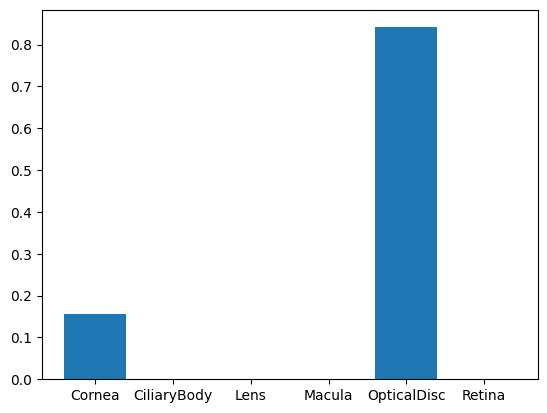

In [149]:
import matplotlib.pyplot as plt
plt.bar(espensen_rois, w);